## K-NN (K-Nearest Neighbors) 알고리즘

### 알고리즘의 원리

![](https://velog.velcdn.com/images/newnew_daddy/post/5cdaac3b-e27d-4a0e-aecb-27296b498d5d/image.png)

1. **거리 측정**: 
- 새로운 데이터 포인트와 기존 데이터 포인트들 간의 거리를 계산.(유클리드 거리, 맨해튼 거리 등) 

2. **K개의 이웃 선택**:
- 가장 가까운 K개의 데이터 포인트를 선택한다. 
- K는 사용자가 설정해야 하는 하이퍼파라미터이며, K의 값에 따라 모델의 성능이 달라질 수 있다.

3. **다수결 투표**:
- 선택된 K개의 이웃 중 가장 많이 등장하는 클래스로 새로운 데이터 포인트를 분류. 
- 예를 들어, K = 3이고, 세 이웃 중 두 개가 클래스 A이고 하나가 클래스 B라면, 새로운 데이터 포인트는 클래스 A로 분류된다.

### K-NN의 특징
- 구현이 간단하고 이해하기 쉬우며, 직관적이다. 복잡한 수학적 모델을 필요로 하지 않는다.
- 데이터의 크기나 스케일에 민감하므로, 일반적으로 데이터 전처리 과정에서 정규화나 표준화가 필요하다.
- 하이퍼파라미터 K는 일반적으로 홀수로 선택하여 투표 결과가 동률이 되는 것을 방지한다.
- 너무 작은 K 값은 모델이 과적합(Overfitting)되는 경향이 있고, 너무 큰 K 값은 모델이 과소적합(Underfitting)되는 경향이 있다.

In [2]:
# sklearn 내장 유방암 진단 데이터셋 (이진 분류, 특성 30개)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
from utils import evaluate_cls_model, plot_cm
np.set_printoptions(suppress=True)  # 과학적 표기 대신 일반 소수로 출력

bc = load_breast_cancer()
X = bc.data
y = bc.target.reshape(-1, 1)  # (n, 1) 형태로 통일

X.shape, y.shape

((569, 30), (569, 1))

In [3]:
# 70% 학습 / 30% 검증, random_state로 분할 재현
train_input, test_input, train_target, test_target = train_test_split(
    X, y, test_size=0.3, random_state=42)

train_input.shape, test_input.shape, train_target.shape, test_target.shape

((398, 30), (171, 30), (398, 1), (171, 1))

In [4]:
# 거리 기반 KNN은 스케일 차이에 민감 → 표준화(평균 0, 분산 1)
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)  # 학습 분포만으로 추정
test_scaled = ss.transform(test_input)        # 검증은 동일 변환만 적용

#### KNN 메소드의 주요 인자 설명

```python
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=5,          # 사용할 이웃의 수. 기본값은 5.
    weights='uniform',      # 가중치 함수. 'uniform'은 모든 이웃에 동일한 가중치를 부여. 'distance'는 거리에 반비례하는 가중치를 부여.
    algorithm='auto',       # 최근접 이웃 검색 알고리즘. ('ball_tree', 'kd_tree', 'brute', 'auto')
    p=2,                    # 거리 측정 방법. p=1은 맨해튼 거리, p=2는 유클리드 거리.
    metric='minkowski',     # 거리 측정 지표. 기본값은 'minkowski'. 다양한 거리 지표 사용 가능.
    n_jobs=None             # 거리 계산에 사용할 CPU 코어 수. -1이면 모든 코어 사용.
)
```

In [5]:
# 가장 가까운 K개 이웃의 다수결로 분류 (K↑ → 경계가 완만해져 과소적합 경향)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(train_scaled, train_target.ravel())  # 1차원 배열로 맞춤


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


=== KNN ===
Train Score: 0.9874
Test  Score: 0.9591

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



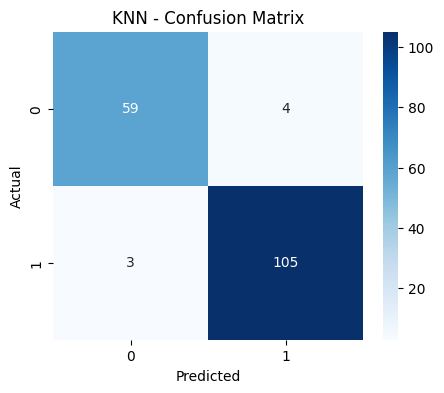

In [ ]:
# Classification_Models.ipynb와 동일: train/test 점수, 리포트 + 혼동 행렬 시각화
y_pred = evaluate_cls_model(knn, train_scaled, test_scaled, train_target, test_target, "KNN")

plot_cm(test_target, y_pred, "KNN")
